# Daisyworld: анимация

Сохраним 60 последовательных состояний модели в анимации GIF.

## Окружение и модель

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

savehistory (generic function with 1 method)

## Наблюдаемые величины

In [2]:
model = daisyworld()
fig = Figure(size = (850, 700))
ax = Axis(
    fig[1, 1],
    title = "Daisyworld",
    xlabel = "x",
    ylabel = "y",
    aspect = 1,
)
temperature = Observable(copy(model.temperature))
black_positions = Observable(Point2f[])
white_positions = Observable(Point2f[])
hm = heatmap!(
    ax,
    temperature;
    colormap = :thermal,
    colorrange = (-20, 60),
)
scatter!(ax, black_positions; color = :black, markersize = 8)
scatter!(ax, white_positions; color = :white, markersize = 8)
Colorbar(fig[1, 2], hm; label = "Температура, °C")

Makie.Colorbar()

## 60 состояний от t = 0 до t = 59

In [3]:
rows = NamedTuple[]
record(
    fig,
    imagefile("01-animation.gif"),
    0:59;
    framerate = 10,
) do frame
    frame > 0 && advance!(model)
    temperature[] = copy(model.temperature)
    black_positions[] = [
        Point2f(a.pos...) for a in allagents(model) if a.breed == :black
    ]
    white_positions[] = [
        Point2f(a.pos...) for a in allagents(model) if a.breed == :white
    ]
    ax.title = "Daisyworld · t=$(model.tick)"
    push!(rows, measure(model))
end

"/workspace/labs/lab03/project/../image/01-animation.gif"

## Данные и последний кадр

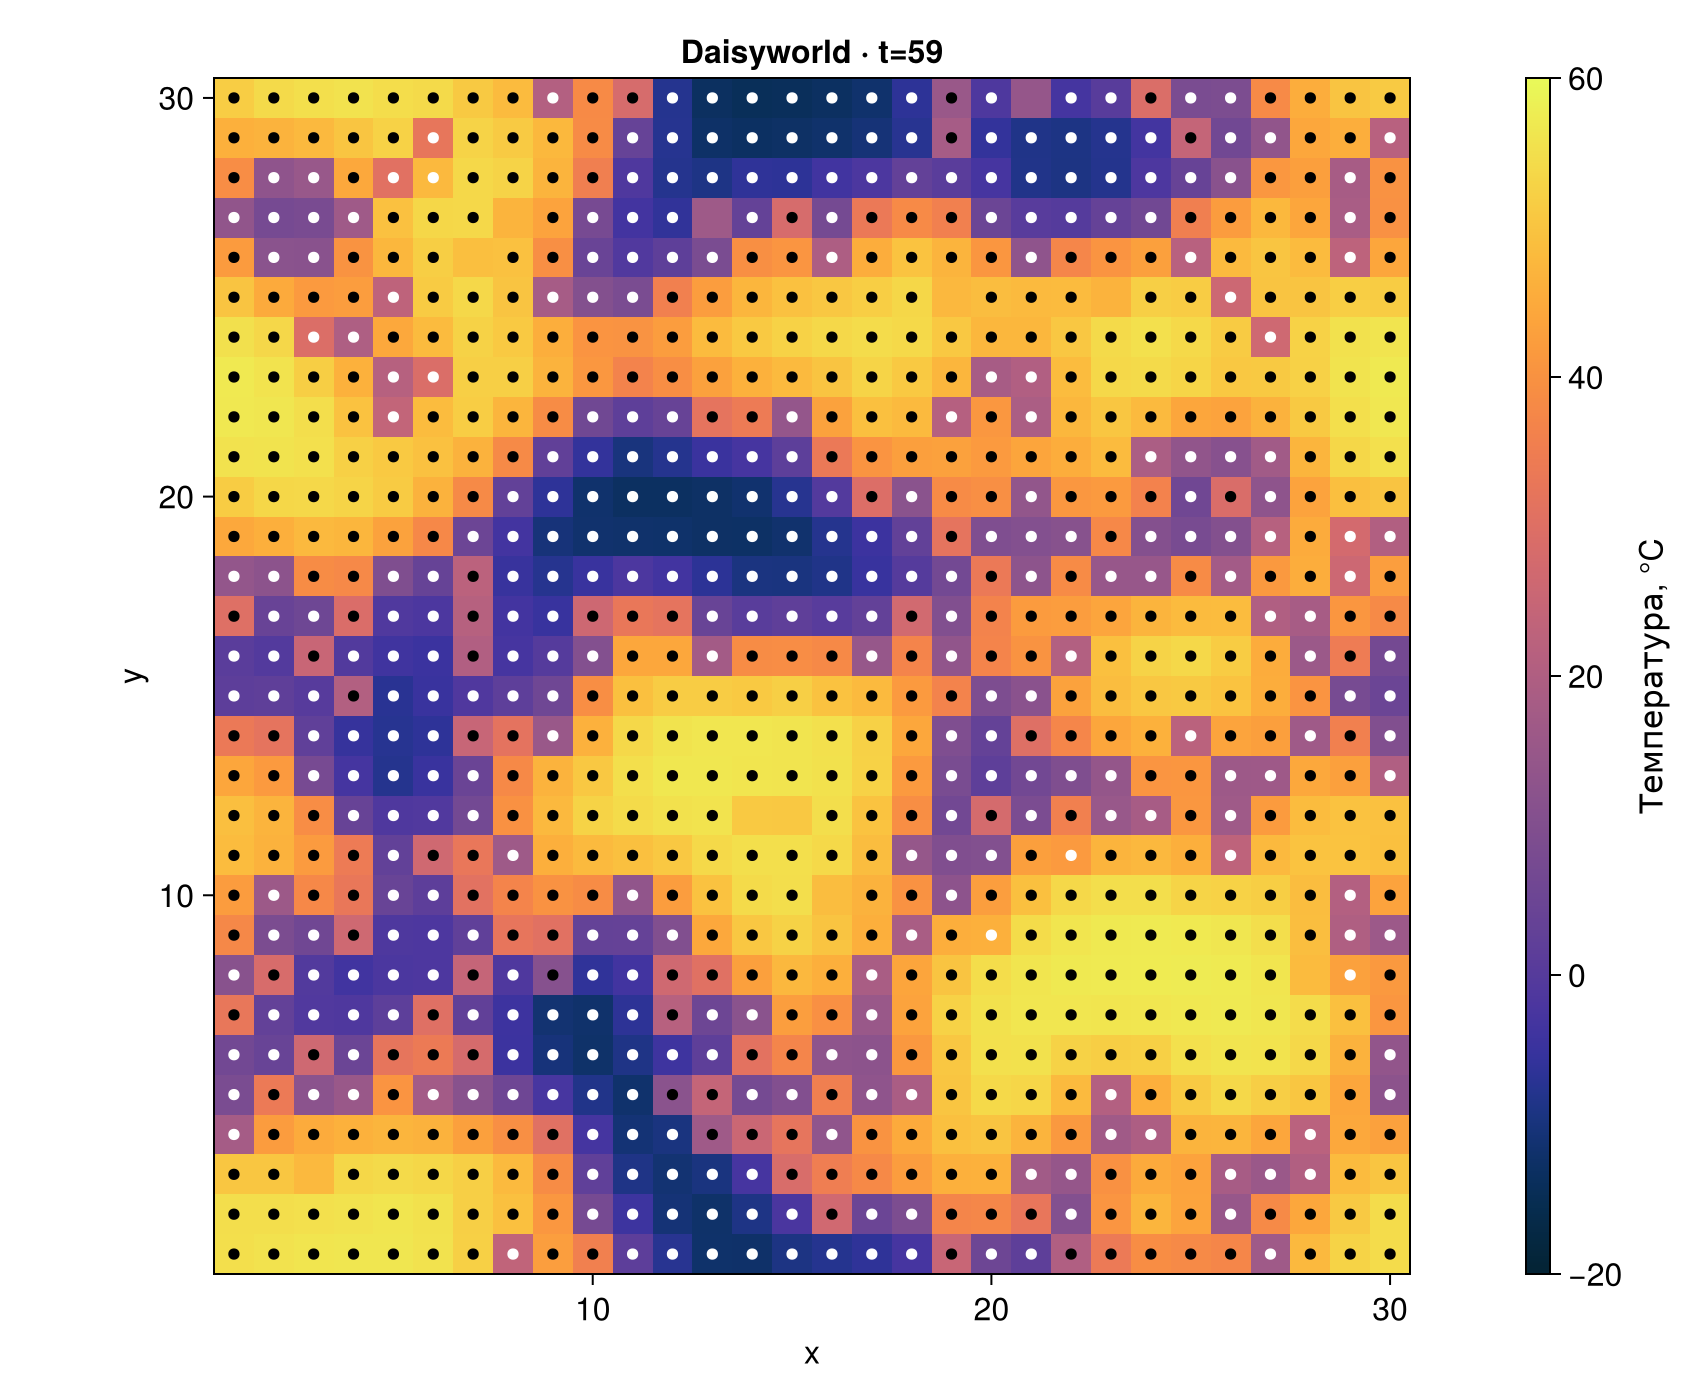

Row,time,black,white,temperature,luminosity,albedo
,Int64,Int64,Int64,Float64,Float64,Float64
1,0,180,180,16.9135,1.0,0.44
2,10,544,354,29.1047,1.0,0.447
3,20,540,359,27.4463,1.0,0.449611
4,30,368,528,13.4671,1.0,0.544
5,40,430,453,17.7977,1.0,0.5045
6,50,480,411,22.1957,1.0,0.479833


In [4]:
CSV.write(datafile("daisyworld-animate", "frames.csv"), DataFrame(rows))
display(fig)
DataFrame(rows)[1:10:end, :]